# Transformers Embeddings

## Import libraries

In [1]:
from sentence_transformers import SentenceTransformer  # import SentenceTransformer for creating embeddings
import pandas as pd  # import pandas for data handling
import numpy as np  # import numpy for numerical operations
from sklearn.metrics.pairwise import cosine_similarity  # import cosine similarity metric
import torch  # import PyTorch
import os  # import os for filesystem access
if torch.cuda.device_count()>0:  # check whether at least one GPU is available
    my_device = "cuda"  # select GPU device
    print(f"You have {torch.cuda.device_count()} GPUs available.")  # report number of GPUs
else:  # otherwise no GPU present
    my_device = "cpu"  # fall back to CPU device
    print("You have no GPUs available. Running on CPU.")  # report that CPU is used

/Users/nefelizafeiropoulou/Documents/Data Science Master/Natural Language Processing/NaturalLanguageProcessing-main/NLPvenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


You have no GPUs available. Running on CPU.


## The SentenceTransformer object

In [2]:
embeddings_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2',  # load pretrained embedding model
                                       cache_folder="./HF-CACHE",  # set local cache directory
                                       device=my_device)  # place the model on the chosen device

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 22513.59it/s]


## Function to visualizing the similarity matrix

In [3]:
import matplotlib.pyplot as plt  # import matplotlib for plotting
def visualize_similarity_matrix(similarity_matrix, items_labels, mat_size=5):  # define heatmap plotting function
    for i in range(similarity_matrix.shape[0]):  # loop over each item/row
        similarity_matrix[i,i] = 0  # zero out the diagonal (self-similarity)
    plt.figure(figsize=(mat_size, mat_size))  # create a square figure
    plt.imshow(similarity_matrix, interpolation='nearest', cmap='viridis')  # draw matrix as a heatmap
    plt.colorbar(label="Cosine Similarity")  # add a colorbar legend
    plt.xticks(ticks=np.arange(len(items_labels)), labels=items_labels, rotation=90, fontsize=8)  # label x-axis ticks
    plt.yticks(ticks=np.arange(len(items_labels)), labels=items_labels, fontsize=8)  # label y-axis ticks
    plt.title("Cosine Similarity Matrix", fontsize=12)  # set the plot title
    plt.tight_layout()  # adjust spacing to avoid clipping
    plt.show()  # display the figure

## Test Embeddings - unrelated words

Cosine Similarity Matrix:
[[0.9999999  0.10814824 0.22320351 0.18859632]
 [0.10814824 1.0000002  0.11285859 0.11104509]
 [0.22320351 0.11285859 1.0000001  0.15452996]
 [0.18859632 0.11104509 0.15452996 1.0000002 ]]


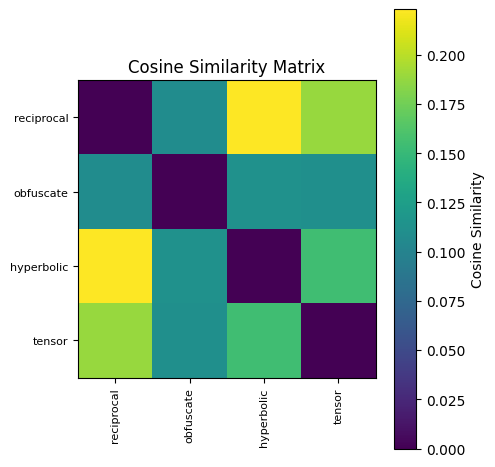

In [4]:
word_list = ["reciprocal", "obfuscate", "hyperbolic", "tensor"]  # list of unrelated words
word_embeddings = embeddings_model.encode(word_list)  # encode words into embedding vectors
cosine_similarities = cosine_similarity(word_embeddings)  # compute pairwise cosine similarities
print("Cosine Similarity Matrix:")  # print header label
print(cosine_similarities)  # print the similarity matrix
visualize_similarity_matrix(cosine_similarities, word_list)  # visualize the similarity matrix

## Test Embeddings - related words

Cosine Similarity Matrix:
[[1.0000002  0.50075734 0.39433044]
 [0.50075734 0.9999999  0.29026115]
 [0.39433044 0.29026115 1.0000002 ]]


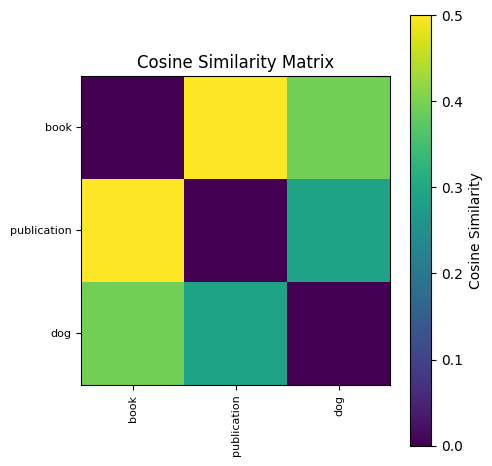

In [5]:
word_list = ["book", "publication", "dog"]  # list of related words
word_embeddings = embeddings_model.encode(word_list)  # encode words into embedding vectors
cosine_similarities = cosine_similarity(word_embeddings)  # compute pairwise cosine similarities
print("Cosine Similarity Matrix:")  # print header label
print(cosine_similarities)  # print the similarity matrix
visualize_similarity_matrix(cosine_similarities, word_list)  # visualize the similarity matrix

## Calculate normalized mean values of embeddings

In [6]:
mean_embeddings = np.mean(np.abs(word_embeddings), axis=1)  # mean of absolute values per embedding
print("Normalized Mean values of embeddings:", mean_embeddings)  # print the mean values
std_embeddings = np.std(word_embeddings, axis=1)  # standard deviation per embedding
print("Standard Deviation of embeddings:", std_embeddings)  # print the standard deviations
norm_embeddings = np.linalg.norm(word_embeddings, axis=1)  # L2 norm per embedding
print("Norm of embeddings:", norm_embeddings)  # print the norms

Normalized Mean values of embeddings: [0.03935564 0.03978137 0.03974741]
Standard Deviation of embeddings: [0.05095434 0.05098887 0.05102683]
Norm of embeddings: [0.99999994 1.         1.        ]


## Generate random vectors with the same mean and std

In [7]:
random_vectors = np.random.normal(loc=np.mean(word_embeddings),  # sample random vectors with same mean
                                  scale=np.std(word_embeddings),  # and the same standard deviation
                                  size=word_embeddings.shape)  # matching the embeddings shape
mean_random_vectors = np.mean(np.abs(random_vectors), axis=1)  # mean of absolute values per random vector
print("Normalized Mean values of random vectors:", mean_random_vectors)  # print random vector means
std_random_vectors = np.std(random_vectors, axis=1)  # standard deviation per random vector
print("Standard Deviation of random vectors:", std_random_vectors)  # print random vector stds
norm_random_vectors = np.linalg.norm(random_vectors, axis=1)  # L2 norm per random vector
print("Norm of random vectors:", norm_random_vectors)  # print random vector norms

Normalized Mean values of random vectors: [0.0392696  0.04198017 0.04034405]
Standard Deviation of random vectors: [0.04912609 0.05375038 0.04998182]
Norm of random vectors: [0.96404467 1.05382149 0.97995125]


Cosine Similarity Matrix random vectors:
[[ 1.          0.02324919 -0.02835041]
 [ 0.02324919  1.         -0.03604276]
 [-0.02835041 -0.03604276  1.        ]]


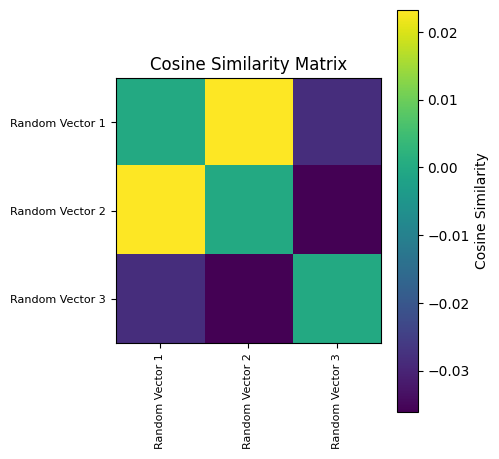

In [8]:
print("Cosine Similarity Matrix random vectors:")  # print header label
cosine_similarities = cosine_similarity(random_vectors)  # compute cosine similarities of random vectors
print(cosine_similarities)  # print the similarity matrix
visualize_similarity_matrix(cosine_similarities, ["Random Vector 1", "Random Vector 2", "Random Vector 3"])  # visualize random vector similarities

## car ~ vehicle + motorcycle - bike

In [9]:
sentences = ["car", "vehicle", "motorcycle", "bike"]  # words for the analogy test
embeddings = embeddings_model.encode(sentences)  # encode the words into embeddings
print(cosine_similarity(embeddings[0].reshape(1, -1), (embeddings[1] + embeddings[2] - embeddings[3]).reshape(1, -1))[0, 0])  # compare car vs vehicle+motorcycle-bike

0.70703584


## Greece ~ Athens + Italy - Rome

In [10]:
sentences = ["Greece", "Athens", "Italy", "Rome"]  # words for the analogy test
embeddings = embeddings_model.encode(sentences)  # encode the words into embeddings
print(cosine_similarity((embeddings[0]).reshape(1, -1), (embeddings[1]+embeddings[2]-embeddings[3]).reshape(1, -1))[0, 0])  # compare Greece vs Athens+Italy-Rome

0.68089765


In [11]:
sentences = ["man", "woman", "king", "queen"] # words for the analogy test
embeddings = embeddings_model.encode(sentences)  # encode the words into embeddings
print(cosine_similarity((embeddings[0]).reshape(1, -1), (embeddings[1]+embeddings[2]-embeddings[3]).reshape(1, -1))[0, 0])  # compare Greece vs Athens+Italy-Rome

0.34649944


## Sentence embeddings

[[ 1.0000002   0.833026    0.80615216  0.01931096 -0.01545598  0.01715532]
 [ 0.833026    1.          0.80017054 -0.00155977 -0.01763441  0.0069328 ]
 [ 0.80615216  0.80017054  1.          0.00830717 -0.03135208 -0.00174041]
 [ 0.01931096 -0.00155977  0.00830717  1.          0.3567573   0.38396114]
 [-0.01545598 -0.01763441 -0.03135208  0.3567573   0.9999998   0.49327675]
 [ 0.01715532  0.0069328  -0.00174041  0.38396114  0.49327675  1.        ]]


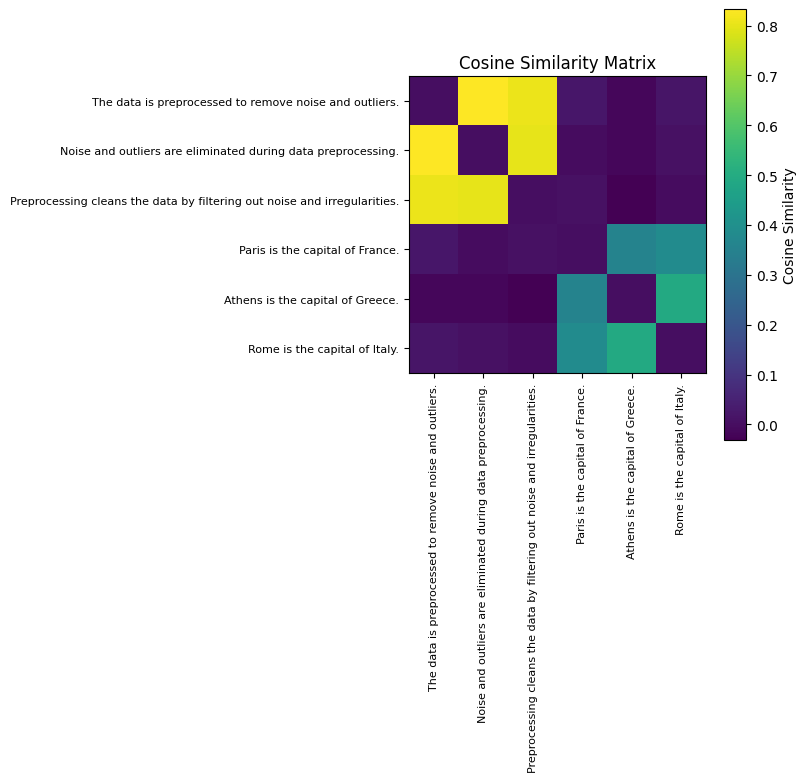

In [12]:
my_sentences = [  # list of sentences to embed
    # Interrelated sentences - group 1
    "The data is preprocessed to remove noise and outliers.",  # group 1 sentence
    "Noise and outliers are eliminated during data preprocessing.",  # group 1 paraphrase
    "Preprocessing cleans the data by filtering out noise and irregularities.",  # group 1 paraphrase

    # Interrelated sentences - group 2
    "Paris is the capital of France.",  # group 2 sentence
    "Athens is the capital of Greece.",  # group 2 sentence
    "Rome is the capital of Italy."  # group 2 sentence
]
my_embeddings = embeddings_model.encode(my_sentences)  # encode all sentences into embeddings
similarity_matrix = cosine_similarity(my_embeddings)  # compute pairwise cosine similarities
print(similarity_matrix)  # print the similarity matrix
visualize_similarity_matrix(similarity_matrix, my_sentences, mat_size=8)  # visualize the similarity matrix

## So embeddings work!

**Hands On 1: Words similarity**

In the following cell, encode the keyword "artificial intelligence"
and compare it to the "deep learning".

Do some experiments with words of your preference.

In [13]:
sentences = ["artificial intelligence", "deep learning"]  # words for the analogy test
embeddings = embeddings_model.encode(sentences)  # encode the words into embeddings
print(cosine_similarity((embeddings[0]).reshape(1, -1), (embeddings[1]).reshape(1, -1))[0, 0])  # compare artificial intelligence vs deep learning

0.5899064


**Hands On 2: Find the most similar word**

In the following cell, define a query word and a list of candidate words.
Encode all of them, compute the similarity of the query to each candidate,
and print the candidate with the highest similarity (use a for loop or np.argmax).

e.g. `query = "dog"`

e.g. `candidates = ["puppy", "car", "wolf", "banana", "cat", "engine"]`

In [14]:
query = "dog"
candidates= ["puppy", "car", "wolf", "banana", "cat", "engine"]  # words for the analogy test
embeddings = embeddings_model.encode(candidates)  # encode the words into embeddings
query_embedding = embeddings_model.encode([query])  # encode the query word into embedding
similarities = cosine_similarity(query_embedding, embeddings)  # compute cosine similarities between query and candidates
best_idx = np.argmax(similarities)

print("Most similar word:", candidates[best_idx])
print("Similarity score:", similarities[0][best_idx])

Most similar word: puppy
Similarity score: 0.80400676


**Hands On 3: Similarity threshold**

In the following cell, take a list of sentences and find every PAIR whose
cosine similarity is above a threshold (e.g. 0.7).

```
sentences = [
    "The cat sat on the mat.",
    "A feline was resting on the rug.",
    "Stock prices fell sharply today.",
    "The market dropped a lot this afternoon.",
    "I enjoy hiking in the mountains."
]
```

TODO: encode the sentences and build the similarity matrix

TODO: loop over pairs i < j and print the pair if similarity > threshold

Discussion: how does changing the threshold change the results?

In [15]:
sentences = [
    "The cat sat on the mat.",
    "A feline was resting on the rug.",
    "Stock prices fell sharply today.",
    "The market dropped a lot this afternoon.",
    "I enjoy hiking in the mountains."
]
embeddings = embeddings_model.encode(sentences)
sim_matrix = cosine_similarity(embeddings)
threshold = 0.5
pairs = []
for i in range(len(sentences)):
    for j in range(i + 1, len(sentences)):
        if sim_matrix[i][j] > threshold:
            pairs.append((sentences[i], sentences[j], sim_matrix[i][j]))
for s1, s2, score in pairs:
    print(f"\nPair:")
    print(f"  1: {s1}")
    print(f"  2: {s2}")
    print(f"  Similarity: {score:.3f}")



Pair:
  1: The cat sat on the mat.
  2: A feline was resting on the rug.
  Similarity: 0.563

Pair:
  1: Stock prices fell sharply today.
  2: The market dropped a lot this afternoon.
  Similarity: 0.584


**Hands On 4: Where embeddings struggle**

In the following cell, compare two sentences that are lexically almost identical
but semantically OPPOSITE, and see what the similarity does.

`s1 = "I love this movie."`

`s2 = "I hate this movie."`

TODO: encode s1 and s2 and print their cosine similarity

Question: the meanings are opposite — why is the similarity still high?

What does this tell you about the limits of cosine similarity for sentiment?

In [16]:
s1 = ["I love this movie"]
s2 = ["I hate this movie"]
embeddings = embeddings_model.encode(s1 + s2)
similarity = cosine_similarity(
    embeddings[0].reshape(1, -1),
    embeddings[1].reshape(1, -1)
)[0][0]
print(f"\nSimilarity between '{s1[0]}' and '{s2[0]}': {similarity:.3f}")



Similarity between 'I love this movie' and 'I hate this movie': 0.715


# Introduction

# Import libraries

In [17]:
from transformers import AutoModelForCausalLM, AutoTokenizer, TextStreamer, pipeline, BitsAndBytesConfig  # import transformers classes/utilities
import os  # import os for filesystem access
import torch  # import PyTorch
import time  # import time for measuring durations
import re  # import regular expressions module

# The Transformers Library

## Download Models

## Model on HF

https://huggingface.co/google/gemma-4-E2B-it

In [18]:
my_model = "Qwen/Qwen3.5-0.8B"  # model identifier to download

In [19]:
tokenizer = AutoTokenizer.from_pretrained(my_model, cache_dir="./HF-CACHE")  # load the model's tokenizer

In [20]:
!nvidia-smi

zsh:1: command not found: nvidia-smi


In [21]:
model = AutoModelForCausalLM.from_pretrained(   my_model,  # load the causal language model
                                                cache_dir="./HF-CACHE",  # set local cache directory
                                                device_map="auto",  # automatically place layers on devices
                                                torch_dtype="auto")  # pick an appropriate dtype automatically

[ERROR] `loss` is part of Qwen3_5CausalLMOutputWithPast.__init__'s signature, but not documented. Make sure to add it to the docstring of the function in /Users/nefelizafeiropoulou/Documents/Data Science Master/Natural Language Processing/NaturalLanguageProcessing-main/NLPvenv/lib/python3.13/site-packages/transformers/models/qwen3_5/modeling_qwen3_5.py.
[ERROR] `logits` is part of Qwen3_5CausalLMOutputWithPast.__init__'s signature, but not documented. Make sure to add it to the docstring of the function in /Users/nefelizafeiropoulou/Documents/Data Science Master/Natural Language Processing/NaturalLanguageProcessing-main/NLPvenv/lib/python3.13/site-packages/transformers/models/qwen3_5/modeling_qwen3_5.py.


[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d
Loading weights: 100%|██████████| 320/320 [00:01<00:00, 259.17it/s]


In [22]:
!nvidia-smi

zsh:1: command not found: nvidia-smi


## pad token

In [23]:
# Depending on the model, the pad token might not be defined
if tokenizer.pad_token is None:  # check whether a pad token is missing
    tokenizer.pad_token = tokenizer.eos_token  # use the end-of-sequence token as pad token
    print("Pad token was None, so it was set to eos token.")  # report the substitution

## Streamer for model.generate and pipeline

In [24]:
streamer = TextStreamer(tokenizer)  # create a streamer to print tokens as they are generated

## Messages

In [25]:
system_instructions = f"You are a helpful assistant."  # define the system prompt
my_messages = [{"role": "system", "content": system_instructions}]  # start the message list with the system role
my_prompt = """Explain Large Language Models (LLMs) briefly in 20 words."""  # define the user prompt
my_messages.append({"role": "user", "content": my_prompt})  # append the user message

## Streaming Model

### Apply chat template to messages and return tensors

In [26]:
inputs = tokenizer.apply_chat_template(my_messages, return_tensors="pt", return_dict=True)  # format messages and tokenize
input_ids = inputs["input_ids"]  # extract the token id tensor
attention_mask = inputs["attention_mask"]   # already there

### Move inputs to GPU if available

In [27]:
if torch.cuda.device_count()>0:  # check whether a GPU is available
    inputs = inputs.to("cuda")  # move inputs to the GPU
    input_ids = input_ids.to("cuda")            # move input_ids to GPU
    attention_mask = attention_mask.to("cuda")  # move attention mask to the GPU
    print("Inputs and Attention Mask transfered to CUDA")  # report the transfer

In [29]:
t1 = time.time()  # record start time
MAXIMUM_TOKENS = 512  # maximum number of new tokens to generate
outputs = model.generate(input_ids,  # generate text from the input ids
                         streamer=streamer,  # stream tokens as they are produced
                         pad_token_id=tokenizer.eos_token_id,  # set the pad token id
                         attention_mask=attention_mask,  # provide the attention mask
                         max_new_tokens=MAXIMUM_TOKENS)  # limit the number of generated tokens
t2 = time.time()  # record end time


<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
Explain Large Language Models (LLMs) briefly in 20 words.<|im_end|>


RuntimeError: Placeholder storage has not been allocated on MPS device!

In [ ]:
print(type(outputs)) # <class 'torch.Tensor'>

NameError: name 'outputs' is not defined

### Clean the response

In [ ]:
generated_text = tokenizer.decode(outputs[0],  # decode the generated token ids to text
                                  skip_special_tokens=True,  # drop special tokens
                                  clean_up_tokenization_spaces=True)  # tidy up tokenization spacing
print(f"{generated_text}\n\n{(t2-t1)/60:.2f} minutes")  # print the text and elapsed minutes
print(type(generated_text)) # <class 'str'>

NameError: name 'tokenizer' is not defined

In [ ]:
new_tokens = outputs[0][input_ids.shape[-1]:]            # keep only newly generated tokens
answer = tokenizer.decode(new_tokens,                    # decode just the answer
                          skip_special_tokens=True,
                          clean_up_tokenization_spaces=False)
print(answer)                                            # the assistant's reply, no prompt/system text

NameError: name 'outputs' is not defined

## Inference (without streaming)

In [ ]:
t1 = time.time()  # record start time
MAXIMUM_TOKENS = 128  # maximum number of new tokens to generate
outputs = model.generate(input_ids,  # generate text from the input ids
                         pad_token_id=tokenizer.eos_token_id,  # set the pad token id
                         attention_mask=attention_mask,  # provide the attention mask
                         max_new_tokens=MAXIMUM_TOKENS)  # limit the number of generated tokens
t2 = time.time()  # record end time
generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)  # decode the tokens to text
print(generated_text + "\n\n" + f"{(t2-t1)/60:.2f} minutes")  # print the text and elapsed minutes

NameError: name 'time' is not defined

## The Pipeline object

In [ ]:
pipe = pipeline("text-generation",  # build a text-generation pipeline
                model=model,  # use the loaded model
                tokenizer=tokenizer,  # use the loaded tokenizer
                device_map="auto")  # auto-place on available devices
t1 = time.time()  # record start time
MAXIMUM_TOKENS = 128  # maximum number of new tokens to generate
outputs = pipe(my_messages,  # run the pipeline on the messages
               max_new_tokens=MAXIMUM_TOKENS,  # limit the number of generated tokens
               pad_token_id=pipe.tokenizer.eos_token_id,  # set the pad token id
               streamer=streamer)  # stream tokens as they are produced
t2 = time.time()  # record end time

NameError: name 'pipeline' is not defined

In [ ]:
# In pipeline outputs (not in model.generate) we have the "generated_text" attribute:
print(outputs[0]["generated_text"][-1]['content'] + "\n\n" + f"{(t2-t1)/60:.2f} minutes")  # print the assistant content and elapsed minutes
# [{'generated_text': [{'role': 'system', 'content': 'You are a helful assistant.'},
#                       {'role': 'user', 'content': "...
type(outputs) # <class 'list'>
type(outputs[0]) # <class 'dict'>

NameError: name 'outputs' is not defined

**Hands On 5: Messages History**

Append the assistant's response to the conversation history and ask a follow-up question

`follow_up_question = "What are the main challenges in training LLMs?"`

Run the model again with the updated conversation history and the follow-up question

In [ ]:
# YOUR CODE HERE

**Hands On 6: System vs User Roles**

The system message contains a fake API key and instructs the model not to reveal it. Write a user prompt and try to make the model disclose the key.

`my_prompt = """"""`

Run the model with the same generation pipeline and check whether the assistant reveals the fake API key. Change only the user prompt.

In [ ]:
# YOUR CODE HERE